# 14-2. Autoencoder 이상 탐지

14장에서 threshold, precision, recall을 배웠다.

이번 노트북에서는 예측 확률이 아니라 `복원 오차`에 threshold를 적용한다.

핵심 문장은 이것이다.

```text
정상 데이터는 잘 복원된다.
이상 데이터는 잘 복원되지 않는다.
복원 오차가 크면 이상으로 의심한다.
```


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout

np.random.seed(42)
tf.random.set_seed(42)
rng = np.random.default_rng(42)


## 예제 센서 데이터 만들기

파일이 없어도 실행할 수 있도록 작은 가상 센서 데이터를 만든다.

센서는 세 가지 값을 가진다고 생각하자.

```text
temperature
pressure
vibration
```

정상 데이터는 평소 범위 주변에 모이고,
이상 데이터는 그 범위에서 많이 벗어나게 만든다.


In [2]:

normal = rng.normal(loc=[25, 100, 0.5], scale=[2, 5, 0.1], size=(600, 3))
anomaly = rng.normal(loc=[35, 130, 1.2], scale=[3, 8, 0.2], size=(80, 3))

X = np.vstack([normal, anomaly])
y = np.array([0] * len(normal) + [1] * len(anomaly))

df = pd.DataFrame(X, columns=["temperature", "pressure", "vibration"])
df["label"] = y

df.head()


,temperature,pressure,vibration,label
0,25.609434,94.800079,0.575045,0
1,26.881129,90.244824,0.369782,0
2,25.255681,98.418787,0.498320,0
3,23.293912,104.396990,0.577779,0
4,25.132061,105.636206,0.546751,0


In [3]:

print("데이터 모양:", df.shape)
print("\n라벨 개수:")
print(df["label"].value_counts())

display(df.groupby("label")[["temperature", "pressure", "vibration"]].mean())


데이터 모양: (680, 4)

라벨 개수:
label
0    600
1     80
Name: count, dtype: int64


,temperature,pressure,vibration
label,,,
0,24.917723,99.779822,0.496083
1,34.741821,129.678368,1.133873


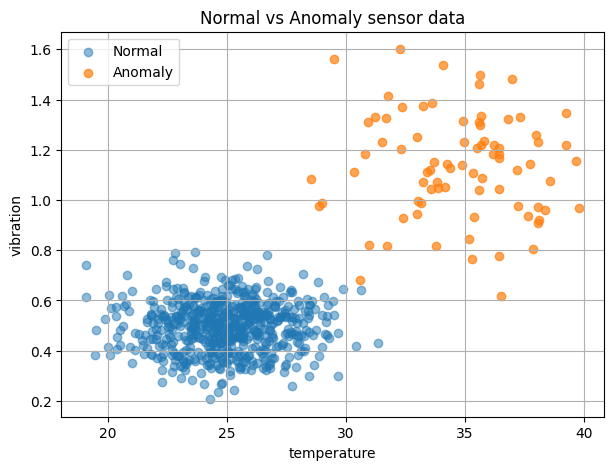

In [4]:

# 정상과 이상 데이터의 분포를 간단히 시각화한다.
plt.figure(figsize=(7, 5))
plt.scatter(df[df["label"] == 0]["temperature"], df[df["label"] == 0]["vibration"], alpha=0.5, label="Normal")
plt.scatter(df[df["label"] == 1]["temperature"], df[df["label"] == 1]["vibration"], alpha=0.7, label="Anomaly")
plt.xlabel("temperature")
plt.ylabel("vibration")
plt.title("Normal vs Anomaly sensor data")
plt.legend()
plt.grid(True)
plt.show()


## 표준화와 학습 데이터 준비

Autoencoder는 정상 패턴을 배우는 것이 목적이다.

그래서 학습에는 정상 데이터만 사용한다.
테스트할 때는 정상과 이상을 모두 넣고, 복원 오차가 이상에서 커지는지 본다.


In [5]:

feature_cols = ["temperature", "pressure", "vibration"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

# label=0인 정상 데이터만 학습에 사용한다.
X_train = X_scaled[df["label"].values == 0]

# 평가는 정상과 이상이 모두 섞인 전체 데이터에서 한다.
X_test = X_scaled
y_test = df["label"].values

print("학습 데이터:", X_train.shape)
print("평가 데이터:", X_test.shape)


학습 데이터: (600, 3)
평가 데이터: (680, 3)


## Autoencoder 모델 만들기

모델은 입력 3개를 받아 다시 3개를 출력한다.

가운데 층은 4개의 값으로 압축한다.
이 부분이 아주 작은 요약 공간이라고 생각하면 된다.


In [6]:

autoencoder = Sequential([
    Input(shape=(3,)),

    # Encoder: 3개 입력을 점점 작은 표현으로 압축한다.
    Dense(16, activation="relu"),
    Dropout(0.1),
    Dense(4, activation="relu"),

    # Decoder: 압축된 표현을 다시 원래 입력 3개 형태로 복원한다.
    Dense(16, activation="relu"),
    Dense(3),
])

# 입력을 다시 입력처럼 복원하는 문제이므로 loss는 MSE를 사용한다.
autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263 (1.03 KB)

 Trainable params: 263 (1.03 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
)

print("마지막 학습 loss:", history.history["loss"][-1])
print("마지막 검증 loss:", history.history["val_loss"][-1])


마지막 학습 loss: 0.027089251205325127
마지막 검증 loss: 0.010534300468862057


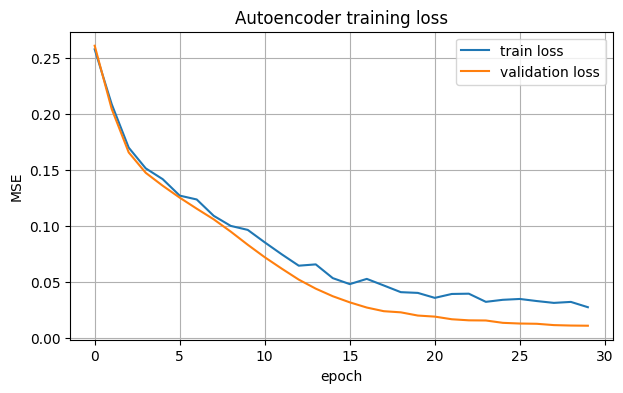

In [8]:

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("Autoencoder training loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()


## 복원 오차 계산하기

학습된 Autoencoder에 데이터를 넣으면 복원된 값이 나온다.

원래 입력과 복원된 입력의 차이를 계산하면 복원 오차가 된다.


In [9]:

X_reconstructed = autoencoder.predict(X_test, verbose=0)

# 각 샘플마다 3개 특성의 제곱 오차 평균을 계산한다.
reconstruction_error = np.mean(np.square(X_test - X_reconstructed), axis=1)

result_df = df.copy()
result_df["reconstruction_error"] = reconstruction_error
result_df.head()


,temperature,pressure,vibration,label,reconstruction_error
0,25.609434,94.800079,0.575045,0,0.000395
1,26.881129,90.244824,0.369782,0,0.002548
2,25.255681,98.418787,0.498320,0,0.001205
3,23.293912,104.396990,0.577779,0,0.001329
4,25.132061,105.636206,0.546751,0,0.001583


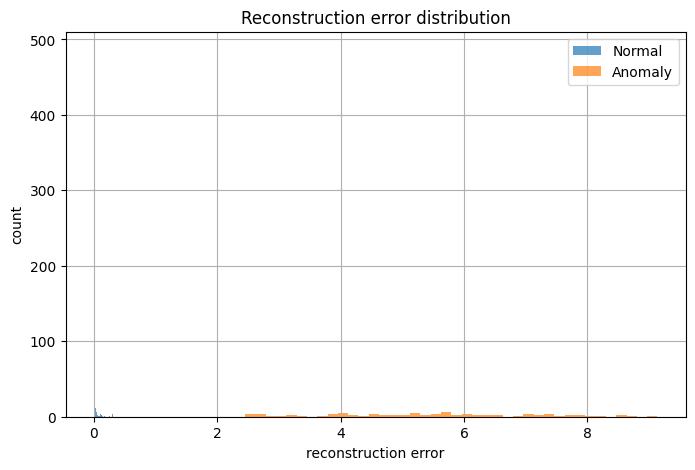

In [10]:

plt.figure(figsize=(8, 5))
plt.hist(result_df[result_df["label"] == 0]["reconstruction_error"], bins=40, alpha=0.7, label="Normal")
plt.hist(result_df[result_df["label"] == 1]["reconstruction_error"], bins=40, alpha=0.7, label="Anomaly")
plt.title("Reconstruction error distribution")
plt.xlabel("reconstruction error")
plt.ylabel("count")
plt.legend()
plt.grid(True)
plt.show()


## threshold 정하기

정상 데이터의 복원 오차를 기준으로 threshold를 정한다.

예를 들어 95% 분위수를 threshold로 쓰면,
정상 데이터 중 복원 오차가 큰 상위 5% 정도는 이상으로 의심될 수 있다.


In [11]:

def evaluate_with_percentile(percentile):
    normal_error = reconstruction_error[y_test == 0]
    threshold = np.percentile(normal_error, percentile)
    y_pred = (reconstruction_error > threshold).astype(int)

    print("=" * 60)
    print(f"threshold percentile: {percentile}%")
    print(f"threshold value: {threshold:.4f}")
    print("confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=["Normal", "Anomaly"]))
    return threshold, y_pred

threshold_95, y_pred_95 = evaluate_with_percentile(95)


threshold percentile: 95%
threshold value: 0.0465
confusion matrix:
[[570  30]
 [  0  80]]
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97       600
     Anomaly       0.73      1.00      0.84        80

    accuracy                           0.96       680
   macro avg       0.86      0.97      0.91       680
weighted avg       0.97      0.96      0.96       680



In [12]:

# threshold를 바꾸면 precision과 recall의 균형이 어떻게 달라지는지 본다.
for percentile in [90, 95, 99]:
    evaluate_with_percentile(percentile)


threshold percentile: 90%
threshold value: 0.0200
confusion matrix:
[[540  60]
 [  0  80]]
              precision    recall  f1-score   support

      Normal       1.00      0.90      0.95       600
     Anomaly       0.57      1.00      0.73        80

    accuracy                           0.91       680
   macro avg       0.79      0.95      0.84       680
weighted avg       0.95      0.91      0.92       680

threshold percentile: 95%
threshold value: 0.0465
confusion matrix:
[[570  30]
 [  0  80]]
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97       600
     Anomaly       0.73      1.00      0.84        80

    accuracy                           0.96       680
   macro avg       0.86      0.97      0.91       680
weighted avg       0.97      0.96      0.96       680

threshold percentile: 99%
threshold value: 0.1541
confusion matrix:
[[594   6]
 [  0  80]]
              precision    recall  f1-score   support

      Normal      

In [13]:

auc = roc_auc_score(y_test, reconstruction_error)
print("ROC-AUC using reconstruction error:", auc)


ROC-AUC using reconstruction error: 1.0


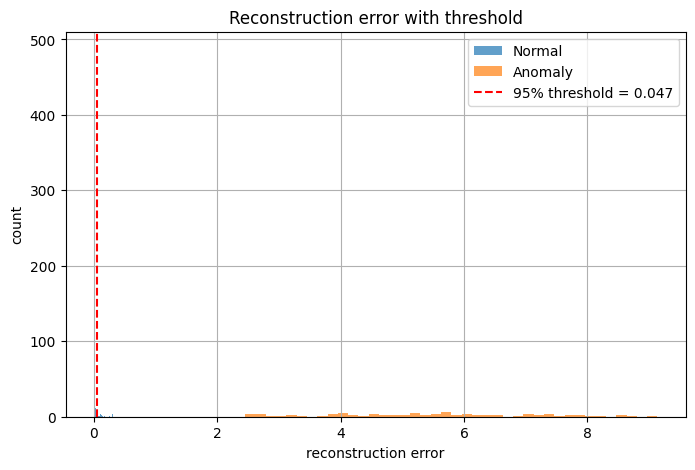

In [14]:

plt.figure(figsize=(8, 5))
plt.hist(result_df[result_df["label"] == 0]["reconstruction_error"], bins=40, alpha=0.7, label="Normal")
plt.hist(result_df[result_df["label"] == 1]["reconstruction_error"], bins=40, alpha=0.7, label="Anomaly")
plt.axvline(threshold_95, color="red", linestyle="--", label=f"95% threshold = {threshold_95:.3f}")
plt.title("Reconstruction error with threshold")
plt.xlabel("reconstruction error")
plt.ylabel("count")
plt.legend()
plt.grid(True)
plt.show()


## 정리

이번 노트북의 흐름은 다음과 같다.

```text
정상 데이터만 사용해 Autoencoder 학습
-> 전체 데이터를 복원
-> 원본과 복원본의 차이 계산
-> 복원 오차에 threshold 적용
-> 이상 여부 판단
```

14장에서 배운 threshold는 여기서도 그대로 중요하다.
다만 기준 숫자가 예측 확률이 아니라 복원 오차라는 점이 다르다.
